In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [27]:
df = pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [29]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [30]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


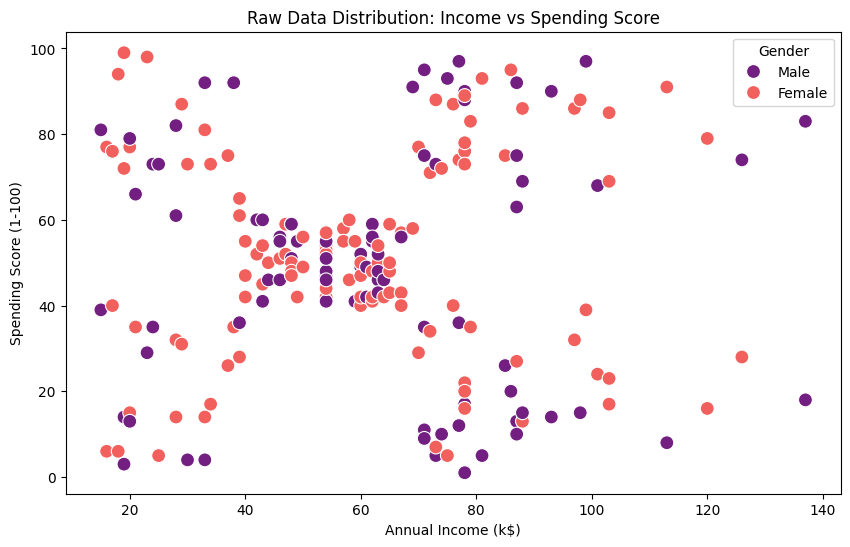

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Gender', palette='magma', s=100)
plt.title('Raw Data Distribution: Income vs Spending Score')
plt.show()

In [32]:
features = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [34]:
sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

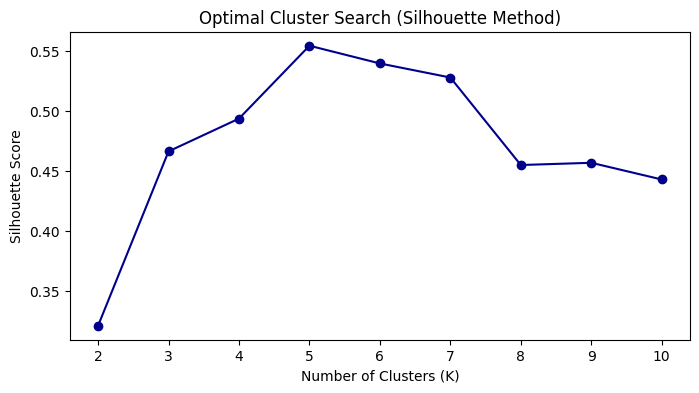

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), sil_scores, marker='o', color='darkblue')
plt.title('Optimal Cluster Search (Silhouette Method)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

In [36]:
final_kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = final_kmeans.fit_predict(X_scaled)

In [37]:
import plotly.express as px
fig = px.scatter(df,x='Annual Income (k$)',y='Spending_Score' if 'Spending_Score' in df else 'Spending Score (1-100)',color='Cluster',size='Age', hover_data=['Gender', 'Age'],title='Final Segments: Professional View',
     color_continuous_scale=px.colors.sequential.Viridis)
fig.update_layout(template='plotly_dark')
fig.show()

In [38]:
analysis = df.groupby('Cluster').agg({'Age': 'mean','Annual Income (k$)': 'mean','Spending Score (1-100)': 'mean'}).round(2)
print(analysis)

           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        42.72               55.30                   49.52
1        32.69               86.54                   82.13
2        25.27               25.73                   79.36
3        41.11               88.20                   17.11
4        45.22               26.30                   20.91


In [39]:
labels = final_kmeans.labels_
score = silhouette_score(X_scaled, df['Cluster'])
print(f"Score {score:0.4f}")

Score 0.5547
